In [1]:
from pathlib import Path
from typing import Literal
from typing_extensions import TypedDict
import json
from datetime import datetime, timedelta
from datetime import date as date_type
from collections import defaultdict
import numpy as np

from langgraph.graph import MessagesState, StateGraph, END
from langgraph.graph.state import CompiledStateGraph

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from sentence_transformers import SentenceTransformer

from IPython.display import Image, display

In [2]:
from src.core.settings import get_settings

get_settings.cache_clear()

def get_llm() -> ChatOpenAI:
    settings = get_settings()
    return ChatOpenAI(
        model=settings.llm_model,
        api_key=settings.openai_api_key,
    )

llm = get_llm()
print(f"LLM: {llm.model_name}, api_key set: {bool(llm.openai_api_key)}")

LLM: gpt-5.4-mini-2026-03-17, api_key set: True


In [3]:
def display_graph(graph: CompiledStateGraph):
    display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from notebooks.evaluation.schemas import RetrievedChunk, RetrievedContext, Report as EvalReport
from src.rag.schemas import WeekReport, MonthReport, YearReport

class DateDict(TypedDict, total=False):
    month: int | None
    year: int
    week: int | None

class ReportState(MessagesState, total=False):
    period: Literal['week', 'month', 'year']
    date: DateDict
    user_id: int
    current_entries: list[dict]
    prev_entries: list[dict]
    sub_period_reports: str | None
    avg_productivity: float
    active_days: int
    goal_metrics_block: str
    language: str
    gender: str | None
    week_report: WeekReport
    month_report: MonthReport
    year_report: YearReport
    final_report: str
    tokens_used: int
    summary_tokens_used: int
    generation_time: float
    context: RetrievedContext

## DB

In [5]:
from src.db.models import Goal, User, Entry, Report
from src.db.session import get_async_sessionmaker

from sqlalchemy import select, extract, func
from sqlalchemy.orm import joinedload

In [6]:
session_factory = get_async_sessionmaker()

## DB helpers (ті самі що в raw_generation)

In [7]:
def prev_date(period: str, date: DateDict) -> DateDict:
    if period == 'week':
        return {**date, 'week': date['week'] - 1}
    elif period == 'month':
        month = date['month']
        year = date['year']
        return {'month': 12 if month == 1 else month - 1,
                'year': year - 1 if month == 1 else year}
    else:
        return {**date, 'year': date['year'] - 1}


def build_where_clause(period: str, date: DateDict, user_id: int):
    user_filter = Goal.user_id == user_id
    if period == 'year':
        return user_filter & (extract('year', Entry.date_note) == date['year'])
    elif period == 'month':
        return (
            user_filter &
            (extract('month', Entry.date_note) == date['month']) &
            (extract('year', Entry.date_note) == date['year'])
        )
    else:
        return (
            user_filter &
            (extract('week', Entry.date_note) == date['week']) &
            (extract('year', Entry.date_note) == date['year'])
        )


async def query_entries(period: str, date: DateDict, user_id: int) -> dict:
    where_clause = build_where_clause(period, date, user_id)

    async with session_factory() as session:
        result = await session.execute(
            select(Goal)
            .options(joinedload(Goal.entries))
            .join(Goal.entries)
            .where(where_clause)
        )
        goals = result.unique().scalars().all()

        metrics = await session.execute(
            select(
                func.round(func.avg(Entry.productivity_score), 2),
                func.count(func.distinct(Entry.date_note)),
            )
            .join(Goal, Entry.goal_id == Goal.id)
            .where(where_clause)
        )
        avg_productivity, active_days = metrics.one()

        raw_entries_result = await session.execute(
            select(Entry)
            .join(Goal, Entry.goal_id == Goal.id)
            .where(where_clause)
            .order_by(Entry.date_note)
        )
        raw_entries = raw_entries_result.scalars().all()

    entries = [
        {'goal_id': goal.id, 'name': goal.title, 'notes': [e.note for e in goal.entries]}
        for goal in goals
    ]

    goal_metrics_lines = []
    for goal in goals:
        if goal.entries:
            active_days_goal = len({e.date_note for e in goal.entries})
            avg_score = sum(e.productivity_score for e in goal.entries) / len(goal.entries)
            goal_metrics_lines.append(
                f'- {goal.id}: {goal.title}: {active_days_goal} active days, avg score {avg_score:.1f}'
            )
    goal_metrics_block = '\n'.join(goal_metrics_lines)

    return {
        'entries': entries,
        'avg_productivity': float(avg_productivity or 0),
        'active_days': int(active_days or 0),
        'goal_metrics_block': goal_metrics_block,
        'raw_entries': raw_entries,
    }


def format_entries(entries: list[dict]) -> str:
    parts = []
    for goal in entries:
        notes_text = '\n'.join(f'- {note}' for note in goal['notes'])
        parts.append(f"**{goal['name']}**\n{notes_text}")
    return '\n\n'.join(parts) if parts else 'No entries.'

## Embedding model + тимчасове сховище

Тут зберігаємо згенеровані звіти під час запуску оцінки.
Тиждень → зберігаємо, місяць підтягує через RAG, місяць → зберігаємо, рік підтягує через RAG.

In [8]:
embedding_model = SentenceTransformer(
    'Alibaba-NLP/gte-multilingual-base', 
    trust_remote_code=True
)

# Тимчасове сховище: (user_id, period) → список збережених звітів
# Живе тільки під час цього запуску ноутбуку
temp_store: dict[tuple, list[dict]] = defaultdict(list)


def clear_temp_store():
    temp_store.clear()


def store_to_temp(user_id: int, period: str, period_start: date_type, text: str):
    """Зберігає згенерований звіт разом з ембедингом."""
    embedding = embedding_model.encode(text, normalize_embeddings=True)
    temp_store[(user_id, period)].append({
        'text': text,
        'embedding': embedding,
        'period_start': period_start,
    })


def extract_goal_summaries(reports: list[dict]) -> list[dict]:
    """З збережених JSON звітів витягує per-goal summaries і групує по goal_id."""
    goals_by_id: dict[int, dict] = {}
    for r in reports:
        try:
            data = json.loads(r['text'])
            period_label = str(r['period_start'])
            for g in data.get('goals', []):
                gid = g.get('goal_id')
                if gid is None:
                    continue
                if gid not in goals_by_id:
                    goals_by_id[gid] = {
                        'goal_id': gid,
                        'name': g.get('name', str(gid)),
                        'notes': [],
                    }
                summary = g.get('summary', '')
                if summary:
                    goals_by_id[gid]['notes'].append(f'[{period_label}] {summary}')
        except (json.JSONDecodeError, KeyError, TypeError):
            continue
    return list(goals_by_id.values())


async def generate_goal_summaries(
    user_id: int,
    sub_period: str,
    language: str,
) -> tuple[list[dict], int]:
    """Генерує LLM-підсумок для кожної цілі паралельно. Повертає (results, total_tokens)."""
    import asyncio
    from src.rag.prompts.summary import SUMMARY_TEMPLATE, SUMMARY_LENGTH

    stored = temp_store.get((user_id, sub_period), [])
    if not stored:
        return [], 0

    goal_data = extract_goal_summaries(stored)
    if not goal_data:
        return [], 0

    period_type = 'weekly' if sub_period == 'week' else 'monthly'
    target_length = SUMMARY_LENGTH['month'] if sub_period == 'week' else SUMMARY_LENGTH['year']

    prompts = [
        SUMMARY_TEMPLATE.format(
            period_type=period_type,
            target_length=target_length,
            reports='\n'.join(goal['notes']),
            additional_entries_block='',
            language=language,
        )
        for goal in goal_data
    ]
    responses = await asyncio.gather(*[
        llm.ainvoke([HumanMessage(content=p)]) for p in prompts
    ])

    total_tokens = 0
    result = []
    for goal, response in zip(goal_data, responses):
        if response.usage_metadata:
            total_tokens += response.usage_metadata.get('total_tokens', 0)
        result.append({
            'goal_id': goal['goal_id'],
            'name': goal['name'],
            'notes': [response.content],
        })
    return result, total_tokens

Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


## RAG retrieval з БД

Для місячних та річних звітів — шукаємо схожі записи з МИНУЛИХ periodів через embedding.
Для тижнів RAG не потрібен — занадто короткий period.

In [9]:
async def retrieve_similar_mmr_entries(
    user_id: int,
    query_text: str,
    before_date: date_type,
    top_k: int = 15,
    fetch_k: int = 20,
) -> list[Entry]:
    """Знаходить top-k записів з БД що були ДО before_date, за косинусною подібністю.

    Ембединг рахується в Python (не pgvector) — для experiment з невеликими даними це нормально.
    """
    query_emb = embedding_model.encode(query_text, normalize_embeddings=True)

    async with session_factory() as session:
        result = await session.execute(
            select(Entry)
            .join(Goal, Entry.goal_id == Goal.id)
            .where(Goal.user_id == user_id)
            .where(Entry.embedding.isnot(None))
            .where(Entry.date_note < before_date)
        )
        entries = result.scalars().all()

    if not entries:
        return []

    #mmr
    embeddings_matrix = np.array([list(e.embedding) for e in entries])
    relevance = embeddings_matrix @ query_emb  # (N,)

    fetch_k = min(fetch_k, len(entries))
    candidate_idx = np.argsort(relevance)[::-1][:fetch_k].tolist()
    candidate_relevance = relevance[candidate_idx]
    candidate_embs = embeddings_matrix[candidate_idx]

    selected_local = []
    for _ in range(min(top_k, fetch_k)):
        if not selected_local:
            best_local = int(np.argmax(candidate_relevance))
        else:
            selected_embs = candidate_embs[selected_local]
            redundancy = (candidate_embs @ selected_embs.T).max(axis=1)
            mmr_score = 0.5 * candidate_relevance - 0.5 * redundancy
            mmr_score[selected_local] = -np.inf
            best_local = int(np.argmax(mmr_score))
        selected_local.append(best_local)

    return [entries[candidate_idx[i]] for i in selected_local]

## Retrieve entries

In [10]:
def make_source_chunks(raw_entries: list) -> list[RetrievedChunk]:
    """Перетворює поточні записи в RetrievedChunk для faithfulness."""
    return [
        RetrievedChunk(
            entry_id=e.id,
            text=e.note,
            embedding=list(e.embedding) if e.embedding is not None else [],
            date=e.date_note,
            goal_id=e.goal_id,
            relevance_score=1.0,
        )
        for e in raw_entries
    ]


async def count_available_months(user_id: int, before_date: date_type) -> int:
    async with session_factory() as session:
        result = await session.execute(
            select(Entry.date_note)
            .join(Goal, Entry.goal_id == Goal.id)
            .where(Goal.user_id == user_id)
            .where(Entry.date_note < before_date)
        )
        dates = result.scalars().all()
    return len({d.strftime("%Y-%m") for d in dates})


async def compute_pool_avg_similarity(user_id: int, before_date: date_type) -> float | None:
    """Avg pairwise cosine similarity of the full historical pool."""
    async with session_factory() as session:
        result = await session.execute(
            select(Entry)
            .join(Goal, Entry.goal_id == Goal.id)
            .where(Goal.user_id == user_id)
            .where(Entry.date_note < before_date)
            .where(Entry.embedding.isnot(None))
        )
        entries = result.scalars().all()
    if len(entries) < 2:
        return None
    mat = np.array([list(e.embedding) for e in entries], dtype=np.float32)
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    mat = mat / norms
    sim = mat @ mat.T
    n = len(mat)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    return float(sim[mask].mean())


async def retrieve_entries(state: ReportState):
    period = state['period']
    date = state['date']
    user_id = state['user_id']

    current = await query_entries(period, date, user_id)

    async with session_factory() as session:
        user = await session.get(User, user_id)
        language = user.language
        gender = user.gender

    source_chunks = make_source_chunks(current['raw_entries'])
    goal_metrics_block = current['goal_metrics_block']

    if period == 'week':
        return {
            'current_entries': current['entries'],
            'prev_entries': [],
            'sub_period_reports': None,
            'summary_tokens_used': 0,
            'avg_productivity': current['avg_productivity'],
            'active_days': current['active_days'],
            'goal_metrics_block': goal_metrics_block,
            'language': language,
            'gender': gender,
            'context': RetrievedContext(
                moment_chunks=None,
                pattern_reports=None,
                source_chunks=source_chunks if source_chunks else None,
                goal_metrics_block=goal_metrics_block or None,
            ),
        }

    elif period == 'month':
        month_dt = date_type(date['year'], date['month'], 1)
        total_available_months = await count_available_months(user_id, month_dt)
        pool_sim = await compute_pool_avg_similarity(user_id, month_dt)

        goal_summaries, summary_tokens = await generate_goal_summaries(user_id, 'week', language)

        if goal_summaries:
            current_entries = goal_summaries
            sub_period_reports = format_entries(current_entries)

            all_past_entries: list[Entry] = []
            prev_entries = []
            for goal in goal_summaries:
                query = goal['notes'][0]
                past = await retrieve_similar_mmr_entries(user_id, query, before_date=month_dt, top_k=5)
                if past:
                    prev_entries.append({
                        'goal_id': goal['goal_id'],
                        'name': goal['name'],
                        'notes': [e.note for e in past],
                    })
                    all_past_entries.extend(past)
        else:
            current_entries = current['entries']
            sub_period_reports = None
            query_text = format_entries(current['entries'])
            all_past_entries = await retrieve_similar_mmr_entries(user_id, query_text, before_date=month_dt, top_k=10)
            past_by_goal: dict[int, list[str]] = defaultdict(list)
            for e in all_past_entries:
                past_by_goal[e.goal_id].append(e.note)
            prev_entries = [
                {'goal_id': gid, 'name': str(gid), 'notes': notes}
                for gid, notes in past_by_goal.items()
            ]

        moment_chunks = [
            RetrievedChunk(
                entry_id=e.id,
                text=e.note,
                embedding=list(e.embedding) if e.embedding is not None else [],
                date=e.date_note,
                goal_id=e.goal_id,
                relevance_score=1.0,
            )
            for e in all_past_entries
        ]
        pattern_reports = [
            EvalReport(report_id=g['goal_id'], text=g['notes'][0], period='week')
            for g in goal_summaries
        ] if goal_summaries else None
        context = RetrievedContext(
            moment_chunks=moment_chunks if moment_chunks else None,
            pattern_reports=pattern_reports,
            source_chunks=source_chunks if source_chunks else None,
            total_available_months=total_available_months if total_available_months > 0 else None,
            pool_avg_similarity=pool_sim,
            goal_metrics_block=goal_metrics_block or None,
        )

    else:  # year
        year_dt = date_type(date['year'], 1, 1)
        total_available_months = await count_available_months(user_id, year_dt)
        pool_sim = await compute_pool_avg_similarity(user_id, year_dt)

        goal_summaries, summary_tokens = await generate_goal_summaries(user_id, 'month', language)

        if goal_summaries:
            current_entries = goal_summaries
            sub_period_reports = format_entries(current_entries)

            all_past_entries = []
            prev_entries = []
            for goal in goal_summaries:
                query = goal['notes'][0]
                past = await retrieve_similar_mmr_entries(user_id, query, before_date=year_dt, top_k=15)
                if past:
                    prev_entries.append({
                        'goal_id': goal['goal_id'],
                        'name': goal['name'],
                        'notes': [e.note for e in past],
                    })
                    all_past_entries.extend(past)
        else:
            current_entries = current['entries']
            sub_period_reports = None
            query_text = format_entries(current['entries'])
            all_past_entries = await retrieve_similar_mmr_entries(user_id, query_text, before_date=year_dt, top_k=15)
            past_by_goal: dict[int, list[str]] = defaultdict(list)
            for e in all_past_entries:
                past_by_goal[e.goal_id].append(e.note)
            prev_entries = [
                {'goal_id': gid, 'name': str(gid), 'notes': notes}
                for gid, notes in past_by_goal.items()
            ]

        moment_chunks = [
            RetrievedChunk(
                entry_id=e.id,
                text=e.note,
                embedding=list(e.embedding) if e.embedding is not None else [],
                date=e.date_note,
                goal_id=e.goal_id,
                relevance_score=1.0,
            )
            for e in all_past_entries
        ]
        pattern_reports = [
            EvalReport(report_id=g['goal_id'], text=g['notes'][0], period='month')
            for g in goal_summaries
        ] if goal_summaries else None
        context = RetrievedContext(
            moment_chunks=moment_chunks if moment_chunks else None,
            pattern_reports=pattern_reports,
            source_chunks=source_chunks if source_chunks else None,
            total_available_months=total_available_months if total_available_months > 0 else None,
            pool_avg_similarity=pool_sim,
            goal_metrics_block=goal_metrics_block or None,
        )

    return {
        'current_entries': current_entries,
        'prev_entries': prev_entries,
        'sub_period_reports': sub_period_reports,
        'summary_tokens_used': summary_tokens,
        'avg_productivity': current['avg_productivity'],
        'active_days': current['active_days'],
        'goal_metrics_block': goal_metrics_block,
        'language': language,
        'gender': gender,
        'context': context,
    }

## Final generation (та сама що в raw_generation)

In [11]:
from src.rag.prompts.month_report import MONTH_SYSTEM_TEMPLATE, MONTH_USER_TEMPLATE, MONTH_USER_BASELINE
from src.rag.prompts.week_report import WEEK_SYSTEM_TEMPLATE, WEEK_USER_TEMPLATE
from src.rag.prompts.year_report import YEAR_SYSTEM_TEMPLATE, YEAR_USER_TEMPLATE, YEAR_USER_BASELINE
from src.rag.schemas import WeekReport, MonthReport, YearReport

from langchain_core.messages import SystemMessage, HumanMessage

In [12]:
import time
from calendar import month_name as calendar_month_name


async def create_report(state: ReportState):
    active_days = state['active_days']
    language = state['language']
    gender = state.get('gender') or 'not specified'
    period = state['period']
    date = state['date']
    goal_metrics_block = state.get('goal_metrics_block', '')
    sub_period_reports = state.get('sub_period_reports')
    prev_text = format_entries(state['prev_entries'])

    goals_block = '\n'.join(f"- {e['goal_id']}: {e['name']}" for e in state['current_entries'])

    if period == 'week':
        week_dt = datetime.fromisocalendar(date['year'], date['week'], 1)
        goals_block = '\n'.join(f"- {e['name']}" for e in state['current_entries'])
        user_prompt = WEEK_USER_TEMPLATE.format(
            month_name=calendar_month_name[week_dt.month],
            year=date['year'],
            language=language,
            gender=gender,
            goals_block=goals_block,
            goal_metrics_block=goal_metrics_block,
            active_days=active_days,
            period_start=week_dt.strftime('%d.%m.%Y'),
            period_end=(week_dt + timedelta(days=6)).strftime('%d.%m.%Y'),
            current_entries=format_entries(state['current_entries']),
        )
        schema = WeekReport
        state_key = 'week_report'

    elif period == 'month':
        user_prompt = MONTH_USER_TEMPLATE.format(
            month_name=calendar_month_name[date['month']],
            year=date['year'],
            language=language,
            gender=gender,
            goals_block=goals_block,
            goal_metrics_block=goal_metrics_block,
            active_days=active_days,
            current_entries=sub_period_reports or format_entries(state['current_entries']),
            rag_context=prev_text,
        )
        schema = MonthReport
        state_key = 'month_report'

    else:  # year
        user_prompt = YEAR_USER_TEMPLATE.format(
            year=date['year'],
            language=language,
            gender=gender,
            goals_block=goals_block,
            goal_metrics_block=goal_metrics_block,
            active_days=active_days,
            current_entries=sub_period_reports or format_entries(state['current_entries']),
            rag_context=prev_text,
        )
        schema = YearReport
        state_key = 'year_report'

    system_prompt = {
        'week': WEEK_SYSTEM_TEMPLATE,
        'month': MONTH_SYSTEM_TEMPLATE,
        'year': YEAR_SYSTEM_TEMPLATE,
    }[period]

    t_start = time.time()
    result = await llm.with_structured_output(schema, include_raw=True).ainvoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ])
    generation_time = time.time() - t_start

    if result.get('parsing_error') or result['parsed'] is None:
        raise ValueError(f"Structured output parse failed: {result.get('parsing_error')}")

    report = result['parsed']
    raw_msg = result['raw']
    report_tokens = raw_msg.usage_metadata.get('total_tokens', 0) if raw_msg.usage_metadata else 0
    tokens_used = report_tokens + state.get('summary_tokens_used', 0)

    return {
        state_key: report,
        'final_report': report.model_dump_json(),
        'tokens_used': tokens_used,
        'generation_time': generation_time,
    }

In [13]:
graph = StateGraph(ReportState)
graph.add_node('retrieve_entries', retrieve_entries)
graph.add_node('create_report', create_report)

graph.set_entry_point('retrieve_entries')
graph.add_edge('retrieve_entries', 'create_report')
graph.add_edge('create_report', END)

app = graph.compile()

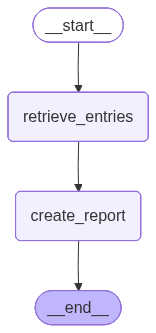

In [14]:
display_graph(app)

## Testing

In [15]:
from datetime import date as date_type

from notebooks.evaluation.langfuse_config import get_langfuse_client
from notebooks.evaluation.schemas import EvaluationLogger, ReportResult
from notebooks.evaluation.evaluate import evaluate_report


async def get_all_users() -> list:
    async with session_factory() as session:
        result = await session.execute(select(User))
        return result.scalars().all()


async def get_user_goal_text(user_id: int) -> str:
    async with session_factory() as session:
        result = await session.execute(
            select(Goal).where(Goal.user_id == user_id)
        )
        goals = result.scalars().all()
    return ', '.join(g.title for g in goals) if goals else 'personal development'


def state_to_report_result(state: dict, user_id: int) -> ReportResult:
    period = state['period']
    d = state['date']

    if period == 'month':
        period_start = date_type(d['year'], d['month'], 1)
    elif period == 'year':
        period_start = date_type(d['year'], 1, 1)
    else:  # week
        period_start = datetime.fromisocalendar(d['year'], d['week'], 1).date()

    return ReportResult(
        context=state.get('context'),
        generated_text=state['final_report'],
        tokens_used=state.get('tokens_used', 0),
        final_generation_time=state.get('generation_time', 0.0),
        method='mmr_rag',
        user_id=user_id,
        period=period,
        period_start=period_start,
    )

In [16]:
async def get_periods_for_user(user_id: int) -> list[tuple[str, dict]]:
    periods = []

    async with session_factory() as session:
        rows = await session.execute(
            select(
                extract('week', Entry.date_note).label('week'),
                extract('year', Entry.date_note).label('year'),
            )
            .join(Goal, Entry.goal_id == Goal.id)
            .where(Goal.user_id == user_id)
            .distinct()
            .order_by('year', 'week')
        )
        for row in rows:
            periods.append(('week', {'week': int(row.week), 'year': int(row.year)}))

        rows = await session.execute(
            select(
                extract('month', Entry.date_note).label('month'),
                extract('year', Entry.date_note).label('year'),
            )
            .join(Goal, Entry.goal_id == Goal.id)
            .where(Goal.user_id == user_id)
            .distinct()
            .order_by('year', 'month')
        )
        for row in rows:
            periods.append(('month', {'month': int(row.month), 'year': int(row.year)}))

        rows = await session.execute(
            select(
                extract('year', Entry.date_note).label('year'),
            )
            .join(Goal, Entry.goal_id == Goal.id)
            .where(Goal.user_id == user_id)
            .distinct()
            .order_by('year')
        )
        for row in rows:
            periods.append(('year', {'year': int(row.year)}))

    return periods

In [17]:
async def run_evaluation():
    import asyncio
    from tqdm.notebook import tqdm

    sem = asyncio.Semaphore(10)
    langfuse = get_langfuse_client()
    logger = EvaluationLogger(
        output_path='results_mmr_rag.csv',
        langfuse=langfuse,
    )

    users = await get_all_users()
    print(f'Users: {[u.id for u in users]}\n')

    for user in tqdm(users, desc='Users'):
        clear_temp_store()
        report_goal = await get_user_goal_text(user.id)
        all_periods = await get_periods_for_user(user.id)

        for target_period in ('week', 'month', 'year'):
            period_subset = [(pt, d) for pt, d in all_periods if pt == target_period]
            if not period_subset:
                continue

            print(f'User {user.id} | {target_period}: {len(period_subset)} reports...')

            async def run_one(period_type, date_dict):
                async with sem:
                    try:
                        state = await app.ainvoke({
                            'period': period_type,
                            'date': date_dict,
                            'user_id': user.id,
                        })
                        if not state or not state.get('final_report'):
                            print(f'  skip: {period_type} {date_dict}')
                            return None
                        report_result = state_to_report_result(state, user.id)
                        store_to_temp(user.id, period_type, report_result.period_start, state['final_report'])
                        await evaluate_report(
                            report_result=report_result,
                            report_goal=report_goal,
                            logger=logger,
                        )
                        return state
                    except Exception as e:
                        print(f'  err  {period_type} {date_dict}  {e}')
                        return None

            tasks = [asyncio.create_task(run_one(pt, d)) for pt, d in period_subset]
            pbar = tqdm(total=len(tasks), desc=f'  {target_period}s', leave=False)

            for coro in asyncio.as_completed(tasks):
                state = await coro
                pbar.update(1)
                if state:
                    pbar.set_postfix(tokens=state.get('tokens_used', '?'), time=f"{state.get('generation_time', 0):.1f}s")

            pbar.close()
            logger.save()

    langfuse.flush()
    print(f'\nDone -- {len(logger.results)} results saved to results_mmr_rag.csv')

In [18]:
await run_evaluation()

2026-04-24 23:46:04,254 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2026-04-24 23:46:04,254 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-24 23:46:04,262 INFO sqlalchemy.engine.Engine select current_schema()
2026-04-24 23:46:04,262 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-24 23:46:04,262 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2026-04-24 23:46:04,262 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-24 23:46:04,274 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-24 23:46:04,284 INFO sqlalchemy.engine.Engine SELECT "user".id, "user".name, "user".email, "user".language, "user".gender 
FROM "user"
2026-04-24 23:46:04,284 INFO sqlalchemy.engine.Engine [generated in 0.00096s] {}
2026-04-24 23:46:04,289 INFO sqlalchemy.engine.Engine ROLLBACK
Users: [21, 22, 23, 24, 25]



Users:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-24 23:46:04,295 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-24 23:46:04,305 INFO sqlalchemy.engine.Engine SELECT goal.id, goal.user_id, goal.title, goal.description, goal.deadline, goal.created_at, goal.status 
FROM goal 
WHERE goal.user_id = %(user_id_1)s::INTEGER
2026-04-24 23:46:04,306 INFO sqlalchemy.engine.Engine [generated in 0.00150s] {'user_id_1': 21}
2026-04-24 23:46:04,311 INFO sqlalchemy.engine.Engine ROLLBACK
2026-04-24 23:46:04,315 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-24 23:46:04,319 INFO sqlalchemy.engine.Engine SELECT DISTINCT EXTRACT(week FROM entry.date_note) AS week, EXTRACT(year FROM entry.date_note) AS year 
FROM entry JOIN goal ON entry.goal_id = goal.id 
WHERE goal.user_id = %(user_id_1)s::INTEGER ORDER BY year, week
2026-04-24 23:46:04,320 INFO sqlalchemy.engine.Engine [generated in 0.00122s] {'user_id_1': 21}
2026-04-24 23:46:04,334 INFO sqlalchemy.engine.Engine SELECT DISTINCT EXTRACT(month FROM entry.date_note) AS month, EX

  weeks:   0%|          | 0/57 [00:00<?, ?it/s]

2026-04-24 23:46:04,362 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-24 23:46:04,366 INFO sqlalchemy.engine.Engine SELECT goal.id, goal.user_id, goal.title, goal.description, goal.deadline, goal.created_at, goal.status, entry_1.id AS id_1, entry_1.goal_id, entry_1.date_note, entry_1.note, entry_1.productivity_score, entry_1.embedding 
FROM goal JOIN entry ON goal.id = entry.goal_id LEFT OUTER JOIN entry AS entry_1 ON goal.id = entry_1.goal_id 
WHERE goal.user_id = %(user_id_1)s::INTEGER AND EXTRACT(week FROM entry.date_note) = %(param_1)s::INTEGER AND EXTRACT(year FROM entry.date_note) = %(param_2)s::INTEGER
2026-04-24 23:46:04,366 INFO sqlalchemy.engine.Engine [generated in 0.00082s] {'user_id_1': 21, 'param_1': 1, 'param_2': 2025}
2026-04-24 23:46:04,441 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-24 23:46:04,441 INFO sqlalchemy.engine.Engine SELECT goal.id, goal.user_id, goal.title, goal.description, goal.deadline, goal.created_at, goal.status, entry_1.id AS id_

...

User 25 | year: 2 reports...


  years:   0%|          | 0/2 [00:00<?, ?it/s]

2026-04-25 00:44:49,504 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-25 00:44:49,505 INFO sqlalchemy.engine.Engine SELECT goal.id, goal.user_id, goal.title, goal.description, goal.deadline, goal.created_at, goal.status, entry_1.id AS id_1, entry_1.goal_id, entry_1.date_note, entry_1.note, entry_1.productivity_score, entry_1.embedding 
FROM goal JOIN entry ON goal.id = entry.goal_id LEFT OUTER JOIN entry AS entry_1 ON goal.id = entry_1.goal_id 
WHERE goal.user_id = %(user_id_1)s::INTEGER AND EXTRACT(year FROM entry.date_note) = %(param_1)s::INTEGER
2026-04-25 00:44:49,507 INFO sqlalchemy.engine.Engine [cached since 2976s ago] {'user_id_1': 25, 'param_1': 2025}
2026-04-25 00:44:49,508 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-25 00:44:49,509 INFO sqlalchemy.engine.Engine SELECT goal.id, goal.user_id, goal.title, goal.description, goal.deadline, goal.created_at, goal.status, entry_1.id AS id_1, entry_1.goal_id, entry_1.date_note, entry_1.note, entry_1.productivity_s

e:\projects\University\BKR\bcr-app\packages\backend\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=YearReport(title='Yearly ...роткі ривки.'), input_type=YearReport])
  return self.__pydantic_serializer__.to_python(
e:\projects\University\BKR\bcr-app\packages\backend\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=YearReport(title='Yearly ... управління.'), input_type=YearReport])
  return self.__pydantic_serializer__.to_python(



Done -- 349 results saved to results_mmr_rag.csv
